In [1]:
import sys
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
from numpy import random
from scipy import stats
import pickle

sys.path.append('/mnt/scripts/biliseq_he_class2')
from helpers import anno as annoHelper
%load_ext autoreload
%autoreload 2

results = Path('/mnt/results/v8/')
models = results.joinpath('models')
use_model = 'densenet169_1fold_1rep_20542bal_224px_v4'
method = 'slide'
csv_path = models.joinpath(use_model).joinpath('csv')
logs = Path('/mnt/logs/v8/training').joinpath('%s_v1' % use_model)
sampleinfo = Path('/mnt/sampleinfo')
slide_df = pd.read_csv(sampleinfo.joinpath('rand_valid_100slides_97cases_v4.tsv'),sep='\t')
infer_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('infer_csv')
feat_path = results.joinpath('features').joinpath(use_model).joinpath('testset')
feat_path.mkdir(parents=True,exist_ok=True)
tile_df = pd.read_csv(feat_path.joinpath('infer_tile_df_1037966t_100slides.csv'))
df_test = pd.read_csv(sampleinfo.joinpath('model_calls_020323.csv'))
print('Finished')

Finished


In [9]:
print(slide_df.shape)
df_test.head()

(100, 20)


,Unnamed: 0,accession_number,location,pathologic_diagnosis,anno_class,follow_up_diagnosis,model_call_best_spec,model_call_prob_pos
0,0,PHS20-10166 - 2 - 1013926,Distal,Negative for Adenocarcinoma,benign,Benign Stricture,benign,0.826724
1,1,PHS20-31037 - 1 - 400130,Hilar,Adenocarcinoma,malignant,Intrahepatic Cholangiocarcinoma,benign,0.940765
2,2,PHS19-7430 - 1014025,Hilar,Adenocarcinoma,malignant,Intrahepatic Cholangiocarcinoma,benign,0.768863
3,3,PHS19-8072 - 1014063,Hilar,Negative for Adenocarcinoma,benign,Benign Stricture,benign,0.003402
4,4,PHS19-1935 - 1014031,Mid,Negative for Adenocarcinoma,benign,Extrahepatic Cholangiocarcinoma,benign,0.329538


# See if incorrect model predictions relate to dx 

In [2]:
y_pred = df_test.model_call_best_spec.values == 'malignant'
y_true = df_test.anno_class.values == 'malignant' 
model_cor =  (y_true == y_pred ) 
df_test.loc[~model_cor,'model_call'] ='Model Incorrect'
df_test.loc[model_cor,'model_call'] ='Model Correct'

fu_neg = df_test.follow_up_diagnosis.isin(['Benign Stricture','Adenoma'])
df_test.loc[fu_neg,'fu_class'] = 'benign'
df_test.loc[~fu_neg,'fu_class'] = 'malignant'
path_cor = (y_true == (df_test.fu_class.values =='malignant'))

both_right = model_cor & path_cor 
df_test.loc[both_right,'model_call'] = 'Model & Path Correct'
both_wrong = (df_test.fu_class.values== 'malignant') & (df_test.anno_class.values =='benign') & (df_test.model_call_best_spec.values =='benign')
df_test.loc[both_wrong,'model_call'] = 'Path & model incorrect'
model_corr_path_wrong = (df_test.fu_class.values== 'malignant') & (df_test.anno_class.values =='benign') & (df_test.model_call_best_spec.values =='malignant')
df_test.loc[model_corr_path_wrong ,'model_call'] = 'Model correct, path incorrect'

path_corr_model_wrong = (df_test.fu_class.values== 'malignant') \
                        & (df_test.anno_class.values =='malignant') \
                        & (df_test.model_call_best_spec.values =='benign')
df_test.loc[path_corr_model_wrong ,'model_call'] = 'Path correct, model wrong'
# model_corr_path_wrong = (df_test.fu_class.values== 'malignant') & (df_test.anno_class.values =='benign') & (df_test.model_call_best_spec.values =='malignant')
# df_test.follow_up_diagnosis[~fu_neg].unique()
# df_test.groupby(['model_call_best_spec','anno_class','model_call']).count()

In [23]:
np.sum((df_test.fu_class.values== 'malignant') & (df_test.anno_class.values =='benign') & (df_test.model_call_best_spec.values =='benign'))

25

In [25]:
df_test.model_call.unique()

array(['Correct', 'Incorrect', 'Path & model incorrect'], dtype=object)

In [19]:
y_pred = df_test.model_call_best_spec.values == 'malignant'
y_true = df_test.anno_class.values == 'malignant' 
model_inc =  (y_true != y_pred ) # y_true &
path_inc = df_test.anno_class.values
print(np.sum(model_inc))

dat = df_test.loc[model_inc,
                       ['accession_number',
                        'location',
                        'pathologic_diagnosis',
                        'follow_up_diagnosis',
                       ]]
dat.head()


25


,accession_number,location,pathologic_diagnosis,follow_up_diagnosis
1,PHS20-31037 - 1 - 400130,Hilar,Adenocarcinoma,Intrahepatic Cholangiocarcinoma
2,PHS19-7430 - 1014025,Hilar,Adenocarcinoma,Intrahepatic Cholangiocarcinoma
12,PHS18-23582 - 2 - 1013809,Hilar,Adenocarcinoma,Intrahepatic Cholangiocarcinoma
13,PHS19-3718 - 2 - 1014033,Hilar,Adenocarcinoma,Intrahepatic Cholangiocarcinoma
17,PHS21-38842 - 1010284 - Malignant FU,Distal,Negative for Adenocarcinoma,Benign Stricture


Text(0.5, 1.0, 'Test BiliSeq Incorrect')

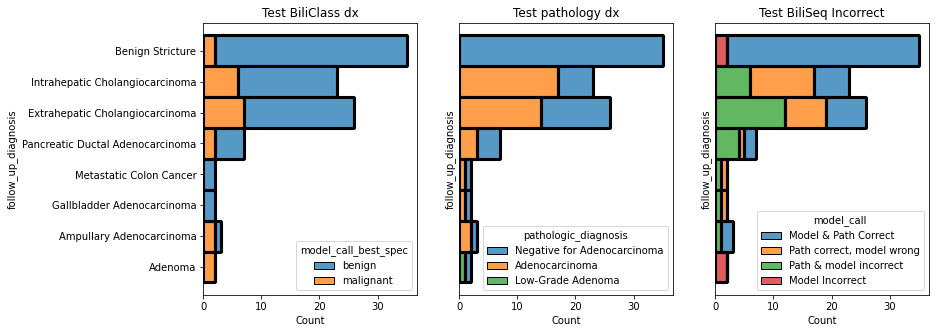

In [3]:

fig = plt.figure(figsize=(13,5))
# ax = fig.add_subplot(2,1,1)
# sns.histplot(y = 'follow_up_diagnosis',
#              data= dat,
#              ax=ax)
# ax.set_title('Model mistakes')

ax = fig.add_subplot(1,3,1)
sns.histplot(y = 'follow_up_diagnosis',
             data= df_test,
             hue = 'model_call_best_spec',
             multiple='stack',
             ax=ax)
ax.set_title('Test BiliClass dx')

ax = fig.add_subplot(1,3,2)
sns.histplot(y = 'follow_up_diagnosis',
             data= df_test,
             hue = 'pathologic_diagnosis',
             multiple='stack',
             ax=ax)
plt.yticks([])
ax.set_title('Test pathology dx')

ax = fig.add_subplot(1,3,3)
sns.histplot(y = 'follow_up_diagnosis',
             data= df_test,
             hue = 'model_call',
             multiple='stack',
             ax=ax)
plt.yticks([])
ax.set_title('Test BiliSeq Incorrect')
# plt.xticks(rotation = 90);

In [53]:
idx = df_test.follow_up_diagnosis.str.contains("Colon Cancer")
idx = (df_test.loc[:,'model_call'] == 'Correct') & (df_test.anno_class.values == 'malignant')

df_test.loc[idx,:]

,Unnamed: 0,accession_number,location,pathologic_diagnosis,anno_class,follow_up_diagnosis,model_call_best_spec,model_call_prob_pos,model_call
11,11,PHS20-26526 - 2 - 373777,Hilar,Adenocarcinoma,malignant,Extrahepatic Cholangiocarcinoma,malignant,0.992678,Correct
14,14,PHS20-21842 - 2 - 352727,Hilar,Adenocarcinoma,malignant,Intrahepatic Cholangiocarcinoma,malignant,0.987975,Correct
18,18,PHS20-2472 - 1 - 255450,Mid,Adenocarcinoma,malignant,Extrahepatic Cholangiocarcinoma,malignant,0.990066,Correct
24,24,PHS18-36373 - 1014039,Hilar,Adenocarcinoma,malignant,Intrahepatic Cholangiocarcinoma,malignant,0.994138,Correct
34,34,PHS21-10602 - 3 - 1011418,Hilar,Adenocarcinoma,malignant,Intrahepatic Cholangiocarcinoma,malignant,0.985014,Correct
47,47,PHS18-13619 - 1013811,Distal,Adenocarcinoma,malignant,Pancreatic Ductal Adenocarcinoma,malignant,0.994498,Correct
49,49,PHS16-712 - 1010341,Mid,Adenocarcinoma,malignant,Extrahepatic Cholangiocarcinoma,malignant,0.992838,Correct
62,62,PHS17-21976 - 1010342,Distal,Adenocarcinoma,malignant,Extrahepatic Cholangiocarcinoma,malignant,0.994778,Correct
77,77,PHS18-25677 - 1014103,Distal,Adenocarcinoma,malignant,Ampullary Adenocarcinoma,malignant,0.978654,Correct
79,79,PHS21-10602 - 1 - 1011415,Hilar,Adenocarcinoma,malignant,Intrahepatic Cholangiocarcinoma,malignant,0.989388,Correct


# Compare to the training set breakdown?

In [40]:
train_df.loc[train_df.follow_up_diagnosis.str.contains('N/A'),:]

,Unnamed: 0,accession_number,pathologic_diagnosis,dob,location,follow_up_diagnosis,notes,phs,section_num,slide_num,...,path_pos,anno_fn,anno_class,raw_fn,anno_pnfn,tile_pn,class,slide,case,group
73,73,PHS22-23675 - 1 - 1,Adenocarcinoma,NaN,NaN,N/A,NaN,PHS22-23675,1.0,PHS22-23675 - 1 - 1,...,True,PHS22-23675 - 1 - 1,multi,PHS22-23675 - 1 - 1.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/PHS22-23675 - 1 - 1,True,PHS22-23675 - 1 - 1,PHS22-23675,malig
74,74,PHS22-23675 - 1 - 2,Adenocarcinoma,NaN,NaN,N/A,NaN,PHS22-23675,2.0,PHS22-23675 - 1 - 2,...,True,PHS22-23675 - 1 - 2,multi,PHS22-23675 - 1 - 2.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/PHS22-23675 - 1 - 2,True,PHS22-23675 - 1 - 2,PHS22-23675,malig
75,75,PHS22-23675 - 1 - 9,Adenocarcinoma,NaN,NaN,N/A,NaN,PHS22-23675,9.0,PHS22-23675 - 1 - 9,...,True,PHS22-23675 - 1 - 9,multi,PHS22-23675 - 1 - 9.svs,/mnt/data/biliseq_he_class/annotations/multi_s...,/mnt/results/v8/tiles/224px/PHS22-23675 - 1 - 9,True,PHS22-23675 - 1 - 9,PHS22-23675,malig


Text(0.5, 0, 'Slides')

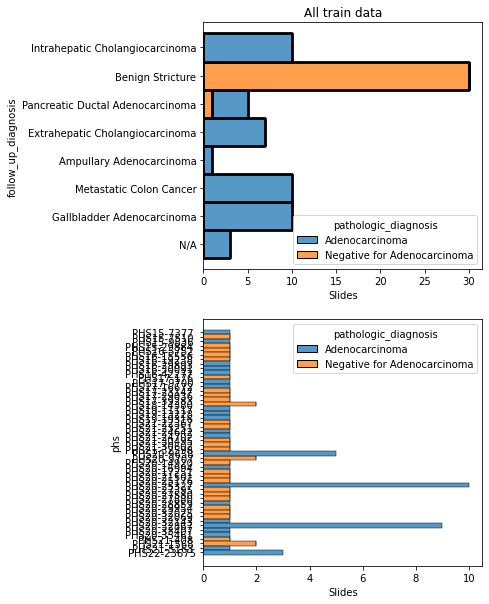

In [36]:
train_df = pd.read_csv('/mnt/sampleinfo/slide_df_v8.0_76_v4.tsv',
                       sep='\t')

train_df.loc[train_df.follow_up_diagnosis.isna(),'follow_up_diagnosis'] = 'N/A'
fig = plt.figure(figsize=(5,10))
ax = fig.add_subplot(2,1,1)

sns.histplot(y = 'follow_up_diagnosis',
             data= train_df,
             hue = 'pathologic_diagnosis',
             multiple='stack',
             ax=ax)
ax.set_title('All train data')
ax.set_xlabel('Slides')
ax = fig.add_subplot(2,1,2)
sns.histplot(y = 'phs',
             data= train_df,
             hue = 'pathologic_diagnosis',
             multiple='stack',
             ax=ax)
ax.set_xlabel('Slides')

# Create prioritized list of malignant cases that should be added

In [4]:
df_test.head()

,Unnamed: 0,accession_number,location,pathologic_diagnosis,anno_class,follow_up_diagnosis,model_call_best_spec,model_call_prob_pos,model_call,fu_class
0,0,PHS20-10166 - 2 - 1013926,Distal,Negative for Adenocarcinoma,benign,Benign Stricture,benign,0.826724,Model & Path Correct,benign
1,1,PHS20-31037 - 1 - 400130,Hilar,Adenocarcinoma,malignant,Intrahepatic Cholangiocarcinoma,benign,0.940765,"Path correct, model wrong",malignant
2,2,PHS19-7430 - 1014025,Hilar,Adenocarcinoma,malignant,Intrahepatic Cholangiocarcinoma,benign,0.768863,"Path correct, model wrong",malignant
3,3,PHS19-8072 - 1014063,Hilar,Negative for Adenocarcinoma,benign,Benign Stricture,benign,0.003402,Model & Path Correct,benign
4,4,PHS19-1935 - 1014031,Mid,Negative for Adenocarcinoma,benign,Extrahepatic Cholangiocarcinoma,benign,0.329538,Path & model incorrect,malignant


In [14]:
path_corr_model_wrong = (df_test.fu_class.values== 'malignant') \
                        & (df_test.anno_class.values =='malignant') \
                        & (df_test.model_call_best_spec.values =='benign')
dat = df_test.loc[path_corr_model_wrong,:]
dat = dat.sort_values(by = 'model_call_prob_pos')
dat = dat.reset_index(drop=True)
dat = dat.drop(columns='Unnamed: 0')
fn = results.joinpath('modeltest100_malig_model_incorrect_ranked_n%d.csv' % (dat.shape[0]))
print(fn)
dat.to_csv(fn)

/mnt/results/v8/modeltest100_malig_model_incorrect_ranked_n21.csv
